# GQA visualization notebook

This notebook does four things:

1. finds your local GQA files,
2. loads one valid image and its scene graph,
3. shows the image, graph text, and graph visualization,
4. shows the existing GQA questions and answers for the same image.

Unlike OpenPSG, GQA already includes rich text in the question files, so you usually do not need a separate prompt-only notebook.

## Expected folder layout

A simple layout that works with this notebook is:

```text
GQA/
  images/
  sceneGraphs/
    train_sceneGraphs.json
    val_sceneGraphs.json
  questions/
    train_balanced_questions.json
    val_balanced_questions.json
    test_balanced_questions.json
    testdev_balanced_questions.json

```

The notebook also accepts a few common alternatives such as `questions1.2/` and `images/images/`.

In [16]:
from pathlib import Path
import json
import random
import textwrap

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

## Configuration

This cell handles the common case where the notebook is stored in `data_analysis/` but the `GQA/` folder is in the project root.

You can set `IMAGE_ID` if you want a fixed example. Otherwise the notebook will choose a valid local sample automatically.

In [17]:
NOTEBOOK_DIR = Path.cwd().resolve()      # current notebook working directory
PROJECT_ROOT = NOTEBOOK_DIR.parent       # go up from data_analysis to project root

ROOT = PROJECT_ROOT / "GQA"
ROOT_OUT = NOTEBOOK_DIR / "outputs"

SCENE_GRAPHS_DIR = ROOT / "sceneGraphs"
QUESTIONS_DIR = ROOT / "questions"
IMAGES_DIR = ROOT / "images"

TRAIN_SCENE_GRAPH_FILE = SCENE_GRAPHS_DIR / "train_sceneGraphs.json"
VAL_SCENE_GRAPH_FILE = SCENE_GRAPHS_DIR / "val_sceneGraphs.json"

TRAIN_QUESTION_FILE = QUESTIONS_DIR / "train_balanced_questions.json"
VAL_QUESTION_FILE = QUESTIONS_DIR / "val_balanced_questions.json"

IMAGE_ID = None          # example: "2407890"
IMAGE_PATH = None        # example: IMAGES_DIR / f"{IMAGE_ID}.jpg"
REQUIRE_QUESTIONS = True
MAX_OBJECTS_TO_DRAW = 20
MAX_RELATIONS_TO_DRAW = 24
MAX_QA_TO_SHOW = 6
RANDOM_SEED = 42
MAX_RANDOM_TRIES = 10000

ROOT_OUT.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("ROOT:", ROOT)
print("ROOT exists:", ROOT.exists())
print("ROOT_OUT:", ROOT_OUT)


NOTEBOOK_DIR: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\data_analysis
PROJECT_ROOT: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward
ROOT: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\GQA
ROOT exists: True
ROOT_OUT: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\data_analysis\outputs


## Helper functions

These helpers:
- find scene graph files,
- find question files,
- generate a simple text summary from the graph,
- choose an available or fallback text prompt,
- and build graph visualizations.


In [18]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_scene_graphs():
    scene_graphs = {}
    for path in [TRAIN_SCENE_GRAPH_FILE, VAL_SCENE_GRAPH_FILE]:
        if path.exists():
            scene_graphs.update(load_json(path))

    if not scene_graphs:
        raise FileNotFoundError("Could not find GQA scene graphs under GQA/sceneGraphs/.")
    return scene_graphs


def load_questions():
    question_data = {}
    used_files = []
    for path in [TRAIN_QUESTION_FILE, VAL_QUESTION_FILE]:
        if path.exists():
            content = load_json(path)
            if isinstance(content, dict):
                question_data.update(content)
                used_files.append(str(path))
    return question_data, used_files


def object_area(obj):
    return int(obj.get("w", 0)) * int(obj.get("h", 0))


def sorted_objects(scene):
    items = list(scene.get("objects", {}).items())
    items.sort(key=lambda kv: object_area(kv[1]), reverse=True)
    return items


def collect_relations(scene):
    rels = []
    objects = scene.get("objects", {})
    for src_id, obj in objects.items():
        rel_dict = obj.get("relations", {}) or {}
        iterable = rel_dict.values() if isinstance(rel_dict, dict) else rel_dict
        for rel in iterable:
            dst_id = str(rel.get("object"))
            if dst_id in objects:
                rels.append((str(src_id), dst_id, str(rel.get("name", "related to"))))
    return rels


def short_obj_desc(obj):
    attrs = obj.get("attributes", [])[:2]
    name = obj.get("name", "object")
    return f"{' '.join(attrs)} {name}" if attrs else name


def generate_prompts(scene, max_objects=6, max_relations=8):
    objects = scene.get("objects", {})
    top_objects = [obj for _, obj in sorted_objects(scene)[:max_objects]]
    object_prompt = ", ".join(short_obj_desc(obj) for obj in top_objects)

    rel_lines = []
    for src_id, dst_id, rel_name in collect_relations(scene)[:max_relations]:
        src = objects.get(src_id, {})
        dst = objects.get(dst_id, {})
        rel_lines.append(f"{short_obj_desc(src)} {rel_name} {short_obj_desc(dst)}")
    relation_prompt = "; ".join(rel_lines)

    location = scene.get("location")
    weather = scene.get("weather")
    prefix_parts = []
    if location:
        prefix_parts.append(f"in a {location}")
    if weather and str(weather).lower() != "none":
        prefix_parts.append(f"with {weather} weather")
    prefix = "A scene"
    if prefix_parts:
        prefix += " " + " ".join(prefix_parts)

    scene_bits = []
    if object_prompt:
        scene_bits.append(f"containing {object_prompt}")
    if rel_lines:
        scene_bits.append(f"where {', '.join(rel_lines[:4])}")
    scene_prompt = prefix + (" " + "; ".join(scene_bits) if scene_bits else ".")
    if not scene_prompt.endswith("."):
        scene_prompt += "."

    return {
        "object_prompt": object_prompt,
        "relation_prompt": relation_prompt,
        "scene_prompt": scene_prompt,
    }


def questions_for_image(question_data, image_id, max_items=6):
    pairs = []
    for qid, q in question_data.items():
        if str(q.get("imageId")) == str(image_id):
            pairs.append((qid, q))
    pairs.sort(key=lambda x: x[0])
    return pairs[:max_items]


def choose_text_prompt(qa_pairs, prompts):
    for _, q in qa_pairs:
        semantic = str(q.get("semanticStr") or "").strip()
        if semantic:
            return semantic, "semanticStr"

    for _, q in qa_pairs:
        question = str(q.get("question") or "").strip()
        if question:
            return question, "question"

    generated = str(prompts.get("scene_prompt") or "").strip()
    if generated:
        return generated, "generated"

    fallback = str(prompts.get("relation_prompt") or prompts.get("object_prompt") or "Generated prompt unavailable.").strip()
    return fallback, "generated"


def image_path_from_id(image_id):
    return IMAGES_DIR / f"{image_id}.jpg"


def is_valid_sample(image_id, scene_graphs, question_data):
    path = image_path_from_id(image_id)
    if not path.exists():
        return False, path
    if image_id not in scene_graphs:
        return False, path
    if REQUIRE_QUESTIONS and not questions_for_image(question_data, image_id, 1):
        return False, path
    return True, path


def choose_sample(scene_graphs, question_data):
    if IMAGE_PATH is not None:
        path = Path(IMAGE_PATH)
        if not path.exists():
            raise FileNotFoundError(f"Image not found: {path}")
        image_id = path.stem
        valid, _ = is_valid_sample(image_id, scene_graphs, question_data)
        if not valid:
            raise RuntimeError(f"Image id {image_id} does not satisfy the current sample criteria.")
        return image_id, path

    if IMAGE_ID is not None:
        image_id = str(IMAGE_ID)
        valid, path = is_valid_sample(image_id, scene_graphs, question_data)
        if not valid:
            raise RuntimeError(f"Image id {image_id} does not satisfy the current sample criteria.")
        return image_id, path

    rng = random.Random(RANDOM_SEED)
    image_ids = tuple(scene_graphs.keys())
    if not image_ids:
        raise RuntimeError("No scene graph image ids were loaded.")

    for _ in range(MAX_RANDOM_TRIES):
        image_id = str(rng.choice(image_ids))
        valid, path = is_valid_sample(image_id, scene_graphs, question_data)
        if valid:
            return image_id, path

    raise RuntimeError(
        f"Could not find a valid random sample after {MAX_RANDOM_TRIES} attempts. "
        "Try disabling REQUIRE_QUESTIONS or setting IMAGE_ID manually."
    )


def build_graph_for_scene(scene, max_objects=MAX_OBJECTS_TO_DRAW, max_relations=MAX_RELATIONS_TO_DRAW):
    graph = nx.DiGraph()
    objects = scene.get("objects", {})
    relations = collect_relations(scene)[:max_relations]

    for obj_id, obj in sorted_objects(scene)[:max_objects]:
        graph.add_node(obj_id, label=f"{obj.get('name', 'object')} #{obj_id}")

    kept_nodes = set(graph.nodes())
    edge_labels = {}
    for src_id, dst_id, rel_name in relations:
        if src_id in kept_nodes and dst_id in kept_nodes:
            graph.add_edge(src_id, dst_id)
            edge_labels[(src_id, dst_id)] = rel_name

    return graph, edge_labels


def draw_scene_graph(ax, scene, seed=RANDOM_SEED):
    graph, edge_labels = build_graph_for_scene(scene)
    objects = scene.get("objects", {})

    ax.set_title("GQA scene graph")
    ax.axis("off")

    if len(graph.nodes) == 0:
        ax.text(0.5, 0.5, "No graph nodes to draw", ha="center", va="center")
        return

    sizes = []
    labels = {}
    for node in graph.nodes:
        obj = objects[node]
        sizes.append(max(900, min(3800, object_area(obj) * 0.03)))
        labels[node] = graph.nodes[node]["label"]

    pos = nx.spring_layout(graph, seed=seed)
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=sizes)
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=True, arrowsize=14, width=1.2)
    nx.draw_networkx_labels(graph, pos, ax=ax, labels=labels, font_size=8)
    nx.draw_networkx_edge_labels(graph, pos, ax=ax, edge_labels=edge_labels, font_size=7)



## Load the data

This cell loads the scene graphs and the available question files.

In [19]:
scene_graphs = load_scene_graphs()
question_data, used_question_files = load_questions()

print("Scene graphs loaded:", len(scene_graphs))
print("Question files used:")
for path in used_question_files:
    print(" -", path)
print("Total questions loaded:", len(question_data))
print("Images directory:", IMAGES_DIR)


Scene graphs loaded: 85638
Question files used:
 - C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\GQA\questions\train_balanced_questions.json
 - C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\GQA\questions\val_balanced_questions.json
Total questions loaded: 1075062
Images directory: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\GQA\images


## Pick a local sample

The notebook scans the local JPG paths and keeps only one random valid sample:
- it must have a local JPG file,
- it must have a scene graph,
- and it can optionally require at least one question.

Only the chosen image is opened later with PIL.


In [20]:
image_id, image_path = choose_sample(scene_graphs, question_data)
scene = scene_graphs[image_id]
qa_pairs = questions_for_image(question_data, image_id, max_items=MAX_QA_TO_SHOW)
prompts = generate_prompts(scene)
display_prompt, prompt_source = choose_text_prompt(qa_pairs, prompts)

print("Chosen image_id:", image_id)
print("Image path:", image_path)
print("Questions found:", len(qa_pairs))
print("Prompt source:", prompt_source)
print("Display prompt:", display_prompt)



Chosen image_id: 2389036
Image path: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\GQA\images\2389036.jpg
Questions found: 6
Prompt source: semanticStr
Display prompt: select: countertop (1264640)->select: floor (1264639) ->common:  [0, 1]


## Show the plain image

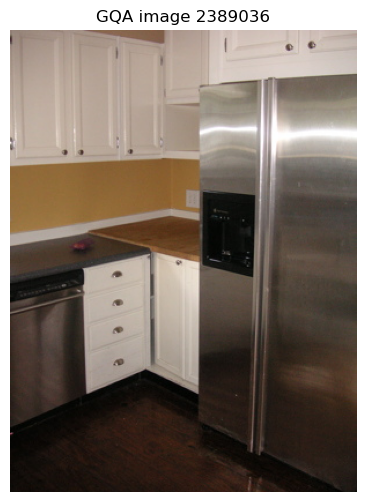

In [21]:
image = np.array(Image.open(image_path).convert("RGB"))
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title(f"GQA image {image_id}")
plt.axis("off")
plt.show()

## Show image, graph, and text prompt together

This block gives an OpenPSG-style side-by-side view:
- the selected image,
- the scene graph,
- and one text prompt.

If a text field is available in GQA, it is used first. Otherwise the notebook falls back to a generated scene prompt.


C:\Users\asus\AppData\Local\Temp\ipykernel_6036\1434458285.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


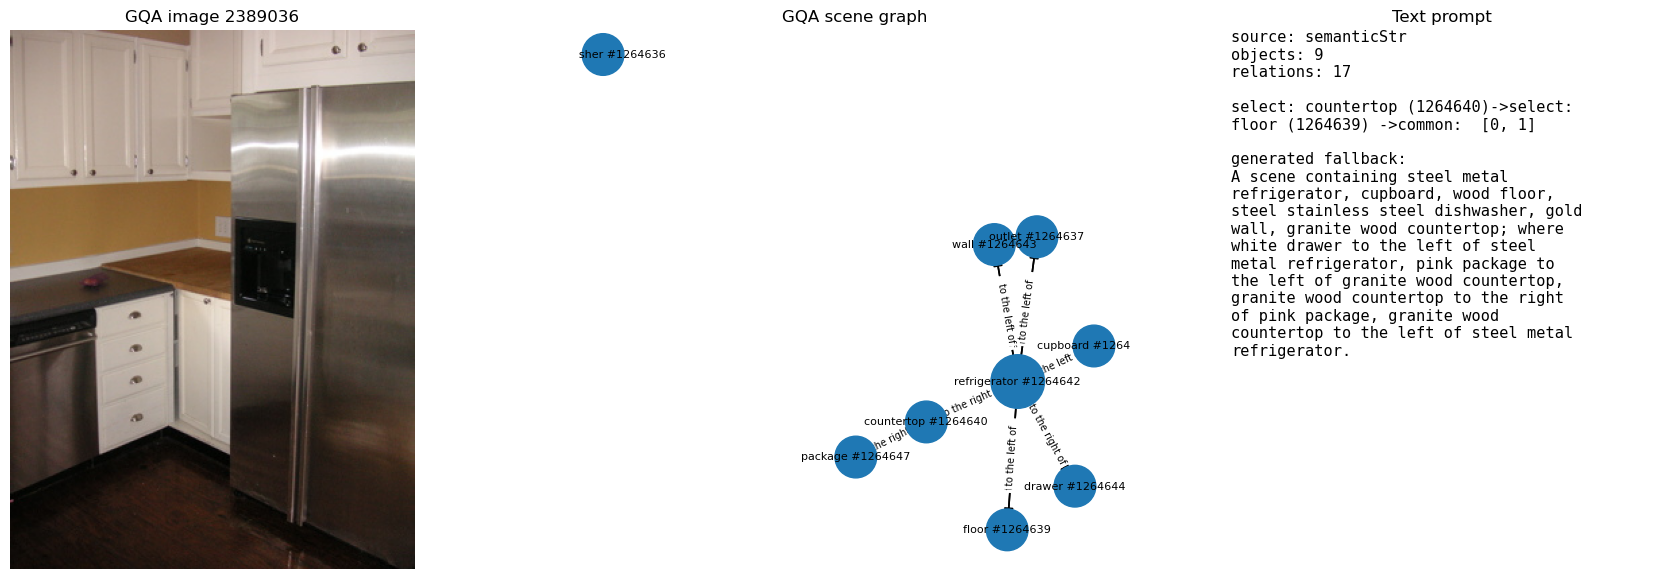

In [22]:
fig = plt.figure(figsize=(22, 7))
grid = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.25, 0.95], wspace=0.2)

ax_img = fig.add_subplot(grid[0, 0])
ax_img.imshow(image)
ax_img.set_title(f"GQA image {image_id}")
ax_img.axis("off")

ax_graph = fig.add_subplot(grid[0, 1])
draw_scene_graph(ax_graph, scene)

ax_text = fig.add_subplot(grid[0, 2])
ax_text.axis("off")
ax_text.set_title("Text prompt")

summary_lines = [
    f"source: {prompt_source}",
    f"objects: {len(scene.get('objects', {}))}",
    f"relations: {len(collect_relations(scene))}",
    "",
    textwrap.fill(display_prompt, width=38),
]

if prompt_source != "generated":
    generated_preview = str(prompts.get("scene_prompt") or "").strip()
    if generated_preview:
        summary_lines.extend([
            "",
            "generated fallback:",
            textwrap.fill(generated_preview, width=38),
        ])

ax_text.text(
    0.0,
    1.0,
    "\n".join(summary_lines),
    ha="left",
    va="top",
    fontsize=11,
    family="monospace",
)

plt.tight_layout()
plt.show()



## Show the image with object boxes

This gives a quick visual check of the main objects in the scene graph.

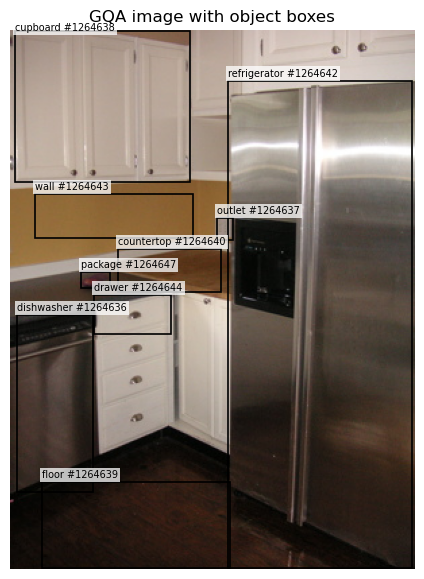

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(image)
ax.set_title("GQA image with object boxes")
ax.axis("off")

for obj_id, obj in sorted_objects(scene)[:MAX_OBJECTS_TO_DRAW]:
    x = int(obj.get("x", 0))
    y = int(obj.get("y", 0))
    w = int(obj.get("w", 0))
    h = int(obj.get("h", 0))
    rect = Rectangle((x, y), w, h, fill=False, linewidth=1.2)
    ax.add_patch(rect)
    ax.text(
        x,
        max(0, y - 3),
        f"{obj.get('name', 'object')} #{obj_id}",
        fontsize=7,
        bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 1.5},
    )

plt.show()

## Graph text and existing GQA text

Here you can inspect:
- generated object / relation / scene prompts,
- graph relations,
- real GQA questions and answers.

In [24]:
lines = []
lines.append(f"location: {scene.get('location')}")
lines.append(f"weather: {scene.get('weather')}")
lines.append(f"objects: {len(scene.get('objects', {}))}")
lines.append(f"relations: {len(collect_relations(scene))}")
lines.append("")
lines.append("display prompt")
lines.append(f"- source: {prompt_source}")
lines.append("- text: " + display_prompt)
lines.append("")
lines.append("generated prompts")
lines.append("- object: " + prompts["object_prompt"])
lines.append("- relation: " + prompts["relation_prompt"])
lines.append("- scene: " + prompts["scene_prompt"])
lines.append("")
lines.append("graph text")
for src_id, dst_id, rel_name in collect_relations(scene)[:MAX_RELATIONS_TO_DRAW]:
    src = scene["objects"][src_id]["name"]
    dst = scene["objects"][dst_id]["name"]
    lines.append(f"- {src} ({src_id}) --{rel_name}--> {dst} ({dst_id})")
lines.append("")
lines.append("gqa questions")
for _, q in qa_pairs:
    lines.append(f"- Q: {q.get('question', '')}")
    lines.append(f"  A: {q.get('fullAnswer') or q.get('answer', '')}")
    if q.get("semanticStr"):
        lines.append(f"  P: {q.get('semanticStr')}")

print("\n".join(lines))



location: None
weather: None
objects: 9
relations: 17

display prompt
- source: semanticStr
- text: select: countertop (1264640)->select: floor (1264639) ->common:  [0, 1]

generated prompts
- object: steel metal refrigerator, cupboard, wood floor, steel stainless steel dishwasher, gold wall, granite wood countertop
- relation: white drawer to the left of steel metal refrigerator; pink package to the left of granite wood countertop; granite wood countertop to the right of pink package; granite wood countertop to the left of steel metal refrigerator; steel metal refrigerator to the right of cupboard; steel metal refrigerator to the right of outlet; steel metal refrigerator to the right of wood floor; steel metal refrigerator to the right of granite wood countertop
- scene: A scene containing steel metal refrigerator, cupboard, wood floor, steel stainless steel dishwasher, gold wall, granite wood countertop; where white drawer to the left of steel metal refrigerator, pink package to the 

## Draw the GQA scene graph

This standalone graph view uses the same helper as the combined panel above.


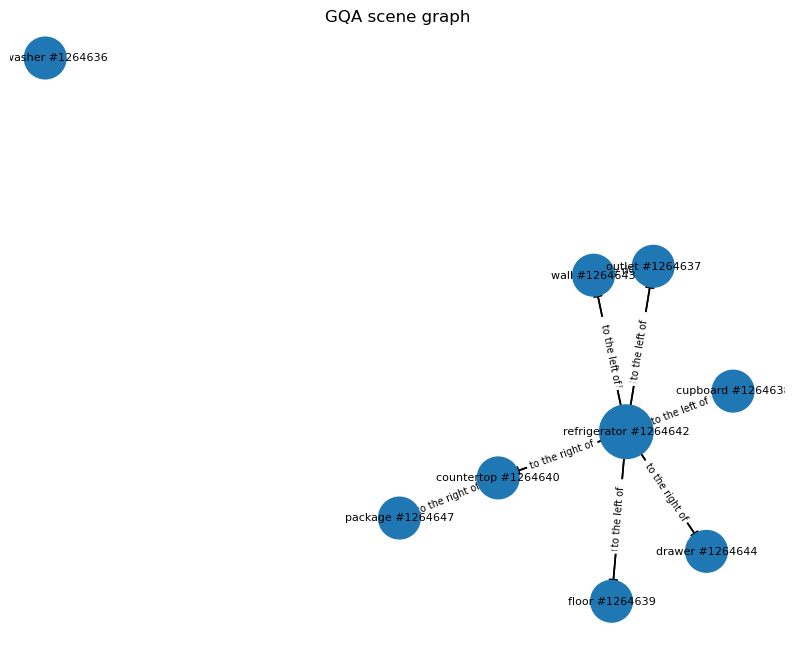

In [25]:
fig, ax_graph = plt.subplots(figsize=(10, 8))
draw_scene_graph(ax_graph, scene)
plt.show()


## Save a summary

This saves a compact JSON summary to `data_analysis/`.

In [26]:
payload = {
    "image_id": image_id,
    "image_path": str(image_path),
    "question_files_used": used_question_files,
    "prompts": prompts,
    "questions": [q for _, q in qa_pairs],
    "object_count": len(scene.get("objects", {})),
    "relation_count": len(collect_relations(scene)),
}

output_json = ROOT_OUT / "gqa_viz_summary.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

print("Saved:", output_json)

Saved: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\data_analysis\outputs\gqa_viz_summary.json
